<a href="https://colab.research.google.com/github/grullaandrea-png/mushroom_classification_model_dervishi/blob/main/Google_net_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir -p /content/dataset
!unzip "/content/drive/MyDrive/Deep_learning_project/archive (9).zip" -d "/content/dataset"

Output streaming troncato alle ultime 5000 righe.
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AE2014PIC62591207.jpg_545e1a0f-1d78-492a-8709-9f5ceb43569f.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AE2014PIC62591207.jpg_e4d7c54d-d437-43fe-b6b5-eab0ddbd559a.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AE2015PIC76548267.jpg_61ebf998-b459-4fc7-8d59-d17a49089c7f.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_ALO2015PIC74715276.jpg_dbd2bff2-da30-47c6-ae31-5cdc47175911.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_ALO2015PIC74715276.jpg_ff6e1280-44e5-44aa-8220-435738b08997.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_ANB2016-9178693_rkxA21PQyx.jpg_89b988b0-c4ae-4c8c-8c92-879b4e0d2a90.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AS2009PIC41853880.jpg_27349cea-c52c-483d-b2dd-e99ced31da85.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AS20

In [3]:
import os

data_dir = '/content/dataset/Data'
print("Classes found:", os.listdir(data_dir))

# where data are estracted
dataset_path = '/content/dataset/Data'

conteggi = {}

if os.path.exists(dataset_path):
    # all class folders
    classi = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

    for classe in classi:
        path_classe = os.path.join(dataset_path, classe)
        n_imagins = len(os.listdir(path_classe))
        conteggi[classe] = n_imagins
        print(f"Class: {classe:<20} | Imagins: {n_imagins}")

    print("-" * 40)
    print(f"Total imagins: {sum(conteggi.values())}")
else:
    print("Error: folder doesn't found")

Classes found: ['Amanita', 'Hygrocybe', 'Entoloma', 'Lactarius', 'Pluteus', 'Exidia', 'Inocybe', 'Suillus', 'Agaricus', 'Boletus', 'Cortinarius', 'Russula']
Class: Amanita              | Imagins: 1000
Class: Hygrocybe            | Imagins: 1000
Class: Entoloma             | Imagins: 1000
Class: Lactarius            | Imagins: 1000
Class: Pluteus              | Imagins: 1000
Class: Exidia               | Imagins: 1000
Class: Inocybe              | Imagins: 1000
Class: Suillus              | Imagins: 1000
Class: Agaricus             | Imagins: 1000
Class: Boletus              | Imagins: 1000
Class: Cortinarius          | Imagins: 1000
Class: Russula              | Imagins: 1000
----------------------------------------
Total imagins: 12000


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import DataLoader, random_split
import os

data_dir = '/content/dataset/Data'

# Trasformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# dataset
dataset_completo = datasets.ImageFolder(data_dir, transform=train_transforms)
dataset_esami = datasets.ImageFolder(data_dir, transform=test_transforms)

total_size = len(dataset_completo)
train_size = int(0.7 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_data, val_data, test_data = random_split(dataset_completo, [train_size, val_size, test_size])

val_data.dataset = dataset_esami
test_data.dataset = dataset_esami

# Dataloaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [5]:
import torch
from torch import nn

class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(BasicConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class Inception(nn.Module):
    def __init__(self, in_channels, c1, c2, c3, c4):
        super(Inception, self).__init__()
        self.p1 = BasicConv2d(in_channels, c1, kernel_size=1)
        self.p2_1 = BasicConv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = BasicConv2d(c2[0], c2[1], kernel_size=3, padding=1)
        self.p3_1 = BasicConv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = BasicConv2d(c3[0], c3[1], kernel_size=5, padding=2)
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = BasicConv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = self.p1(x)
        p2 = self.p2_2(self.p2_1(x))
        p3 = self.p3_2(self.p3_1(x))
        p4 = self.p4_2(self.p4_1(x))
        return torch.cat((p1, p2, p3, p4), dim=1)

b1 = nn.Sequential(BasicConv2d(3, 64, kernel_size=7, stride=2, padding=3), nn.MaxPool2d(3, stride=2, padding=1))
b2 = nn.Sequential(BasicConv2d(64, 64, kernel_size=1), BasicConv2d(64, 192, kernel_size=3, padding=1), nn.MaxPool2d(3, stride=2, padding=1))
b3 = nn.Sequential(Inception(192, 64, (96, 128), (16, 32), 32), Inception(256, 128, (128, 192), (32, 96), 64), nn.MaxPool2d(3, stride=2, padding=1))
b4 = nn.Sequential(Inception(480, 192, (96, 208), (16, 48), 64), Inception(512, 160, (112, 224), (24, 64), 64), Inception(512, 128, (128, 256), (24, 64), 64), Inception(512, 112, (144, 288), (32, 64), 64), Inception(528, 256, (160, 320), (32, 128), 128), nn.MaxPool2d(3, stride=2, padding=1))
b5 = nn.Sequential(Inception(832, 256, (160, 320), (32, 128), 128), Inception(832, 384, (192, 384), (48, 128), 128), nn.AdaptiveAvgPool2d((1,1)), nn.Flatten())

net = nn.Sequential(b1, b2, b3, b4, b5, nn.Dropout(0.4), nn.Linear(1024, 12)) # Aggiunto un po' di Dropout per evitare memoria a pappagallo

In [6]:
# Control if the GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We are using: {device}")

# Put the 'net'on the GPU
model = net.to(device)

We are using: cuda


Epoch [1/50]: 100%|██████████| 263/263 [00:37<00:00,  6.99it/s, loss=2.15]



Results: Train Loss: 2.0680 | Val Loss: 2.1635 | Val Accuracy: 24.83%
--> Improvement! Model saving ... (Accuracy: 0.00% -> 24.83%)


Epoch [2/50]: 100%|██████████| 263/263 [00:35<00:00,  7.31it/s, loss=1.87]



Results: Train Loss: 1.9602 | Val Loss: 1.9070 | Val Accuracy: 35.50%
--> Improvement! Model saving ... (Accuracy: 24.83% -> 35.50%)


Epoch [3/50]: 100%|██████████| 263/263 [00:36<00:00,  7.12it/s, loss=1.88]



Results: Train Loss: 1.9228 | Val Loss: 2.2959 | Val Accuracy: 27.83%


Epoch [4/50]: 100%|██████████| 263/263 [00:36<00:00,  7.19it/s, loss=2.02]



Results: Train Loss: 1.9122 | Val Loss: 2.2119 | Val Accuracy: 26.67%


Epoch [5/50]: 100%|██████████| 263/263 [00:36<00:00,  7.25it/s, loss=2.01]



Results: Train Loss: 1.8986 | Val Loss: 1.9888 | Val Accuracy: 32.33%


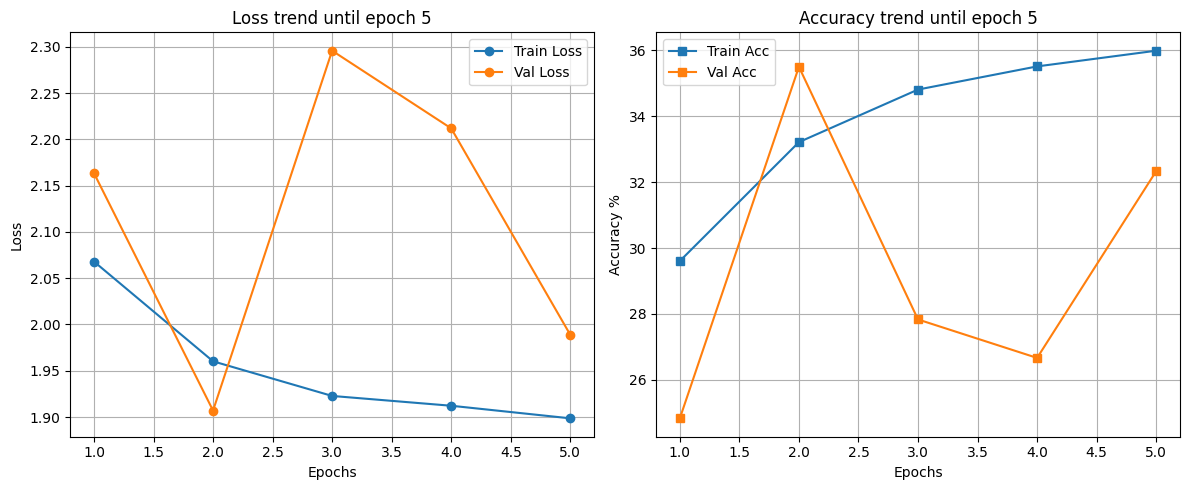

Epoch [6/50]: 100%|██████████| 263/263 [00:36<00:00,  7.14it/s, loss=1.84]



Results: Train Loss: 1.8818 | Val Loss: 2.2529 | Val Accuracy: 25.83%


Epoch [7/50]: 100%|██████████| 263/263 [00:36<00:00,  7.12it/s, loss=2.09]



Results: Train Loss: 1.7589 | Val Loss: 1.9911 | Val Accuracy: 34.83%


Epoch [8/50]: 100%|██████████| 263/263 [00:36<00:00,  7.23it/s, loss=1.65]



Results: Train Loss: 1.7187 | Val Loss: 1.9665 | Val Accuracy: 34.33%


Epoch [9/50]: 100%|██████████| 263/263 [00:37<00:00,  7.10it/s, loss=1.96]



Results: Train Loss: 1.7265 | Val Loss: 1.9762 | Val Accuracy: 33.83%


Epoch [10/50]: 100%|██████████| 263/263 [00:36<00:00,  7.15it/s, loss=1.63]



Results: Train Loss: 1.7019 | Val Loss: 1.9619 | Val Accuracy: 33.58%


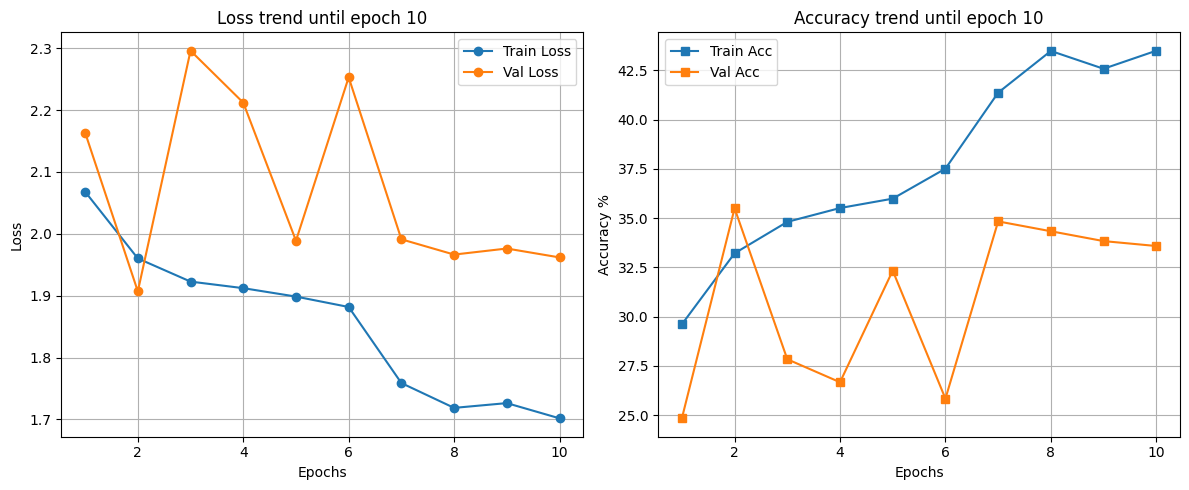

Epoch [11/50]: 100%|██████████| 263/263 [00:36<00:00,  7.18it/s, loss=1.47]



Results: Train Loss: 1.5834 | Val Loss: 1.6606 | Val Accuracy: 44.50%
--> Improvement! Model saving ... (Accuracy: 35.50% -> 44.50%)


Epoch [12/50]: 100%|██████████| 263/263 [00:37<00:00,  7.04it/s, loss=1.34]



Results: Train Loss: 1.5430 | Val Loss: 1.7035 | Val Accuracy: 42.42%


Epoch [13/50]: 100%|██████████| 263/263 [00:36<00:00,  7.21it/s, loss=1.92]



Results: Train Loss: 1.5209 | Val Loss: 1.7121 | Val Accuracy: 42.67%


Epoch [14/50]: 100%|██████████| 263/263 [00:36<00:00,  7.21it/s, loss=1.5]



Results: Train Loss: 1.5247 | Val Loss: 1.5615 | Val Accuracy: 48.92%
--> Improvement! Model saving ... (Accuracy: 44.50% -> 48.92%)


Epoch [15/50]: 100%|██████████| 263/263 [00:37<00:00,  7.10it/s, loss=1.54]



Results: Train Loss: 1.5006 | Val Loss: 1.7970 | Val Accuracy: 41.25%


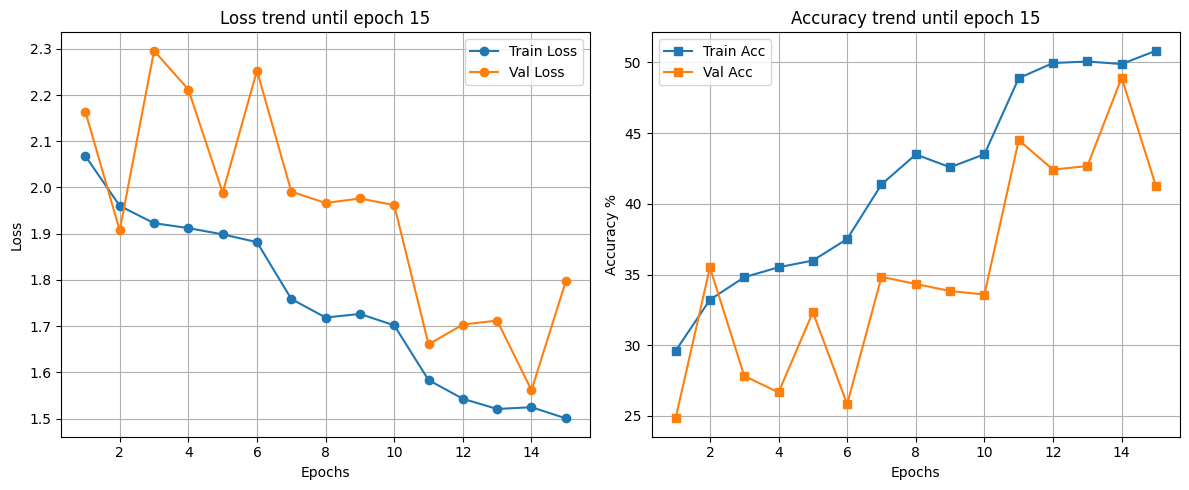

Epoch [16/50]: 100%|██████████| 263/263 [00:36<00:00,  7.18it/s, loss=2.35]



Results: Train Loss: 1.4913 | Val Loss: 1.5099 | Val Accuracy: 48.50%


Epoch [17/50]: 100%|██████████| 263/263 [00:36<00:00,  7.16it/s, loss=1.37]



Results: Train Loss: 1.4687 | Val Loss: 1.7175 | Val Accuracy: 43.50%


Epoch [18/50]: 100%|██████████| 263/263 [00:37<00:00,  7.08it/s, loss=1.3]



Results: Train Loss: 1.4528 | Val Loss: 1.8157 | Val Accuracy: 41.58%


Epoch [19/50]: 100%|██████████| 263/263 [00:36<00:00,  7.15it/s, loss=1.62]



Results: Train Loss: 1.4251 | Val Loss: 1.5100 | Val Accuracy: 50.42%
--> Improvement! Model saving ... (Accuracy: 48.92% -> 50.42%)


Epoch [20/50]: 100%|██████████| 263/263 [00:37<00:00,  7.04it/s, loss=1.53]



Results: Train Loss: 1.4335 | Val Loss: 1.6247 | Val Accuracy: 46.17%


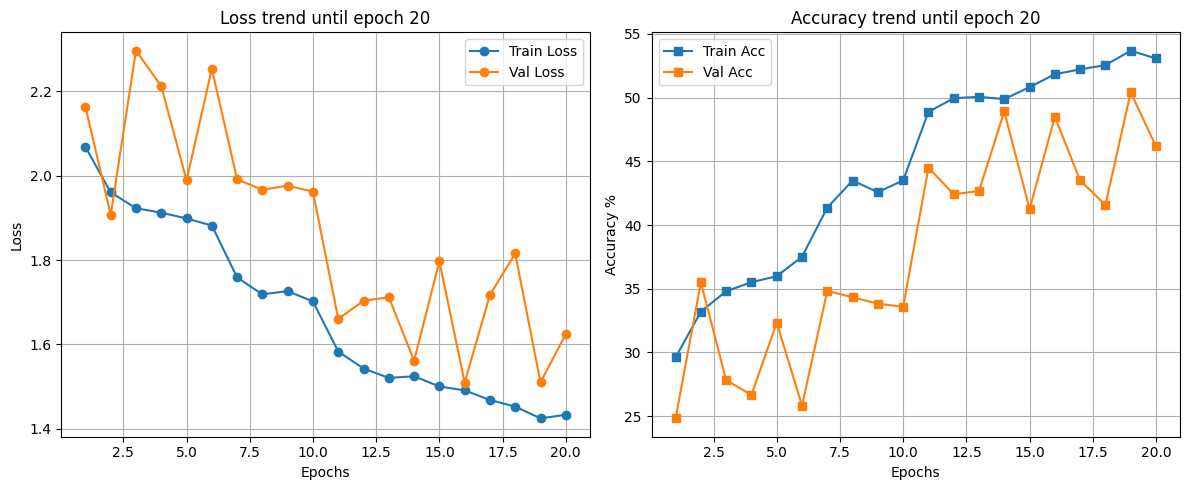

Epoch [21/50]: 100%|██████████| 263/263 [00:37<00:00,  7.05it/s, loss=1.21]



Results: Train Loss: 1.2585 | Val Loss: 1.4975 | Val Accuracy: 50.17%


Epoch [22/50]: 100%|██████████| 263/263 [00:36<00:00,  7.15it/s, loss=1.46]



Results: Train Loss: 1.2120 | Val Loss: 1.3538 | Val Accuracy: 55.67%
--> Improvement! Model saving ... (Accuracy: 50.42% -> 55.67%)


Epoch [23/50]: 100%|██████████| 263/263 [00:37<00:00,  7.06it/s, loss=1.3]



Results: Train Loss: 1.1851 | Val Loss: 1.4610 | Val Accuracy: 51.08%


Epoch [24/50]: 100%|██████████| 263/263 [00:36<00:00,  7.14it/s, loss=1.06]



Results: Train Loss: 1.1750 | Val Loss: 1.3293 | Val Accuracy: 57.83%
--> Improvement! Model saving ... (Accuracy: 55.67% -> 57.83%)


Epoch [25/50]: 100%|██████████| 263/263 [00:37<00:00,  7.04it/s, loss=0.886]



Results: Train Loss: 1.1576 | Val Loss: 1.3577 | Val Accuracy: 56.67%


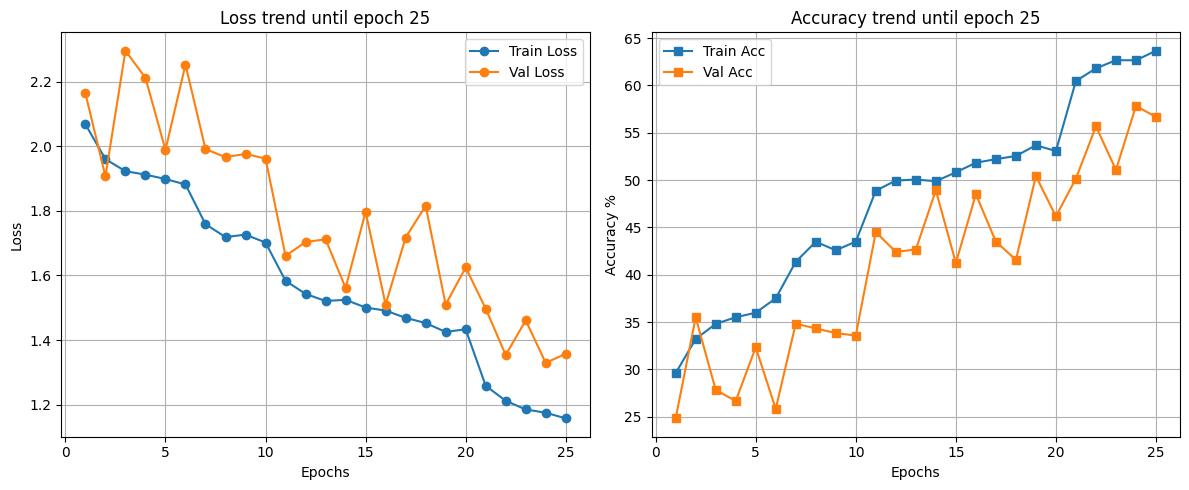

Epoch [26/50]: 100%|██████████| 263/263 [00:37<00:00,  7.09it/s, loss=1.48]



Results: Train Loss: 1.1423 | Val Loss: 1.4866 | Val Accuracy: 53.58%


Epoch [27/50]: 100%|██████████| 263/263 [00:36<00:00,  7.13it/s, loss=1.24]



Results: Train Loss: 1.1343 | Val Loss: 1.6113 | Val Accuracy: 47.42%


Epoch [28/50]: 100%|██████████| 263/263 [00:37<00:00,  7.07it/s, loss=1.17]



Results: Train Loss: 1.1049 | Val Loss: 1.4307 | Val Accuracy: 54.17%


Epoch [29/50]: 100%|██████████| 263/263 [00:36<00:00,  7.14it/s, loss=1.52]



Results: Train Loss: 0.9559 | Val Loss: 1.0810 | Val Accuracy: 67.00%
--> Improvement! Model saving ... (Accuracy: 57.83% -> 67.00%)


Epoch [30/50]: 100%|██████████| 263/263 [00:37<00:00,  7.02it/s, loss=0.762]



Results: Train Loss: 0.8963 | Val Loss: 1.0681 | Val Accuracy: 66.92%


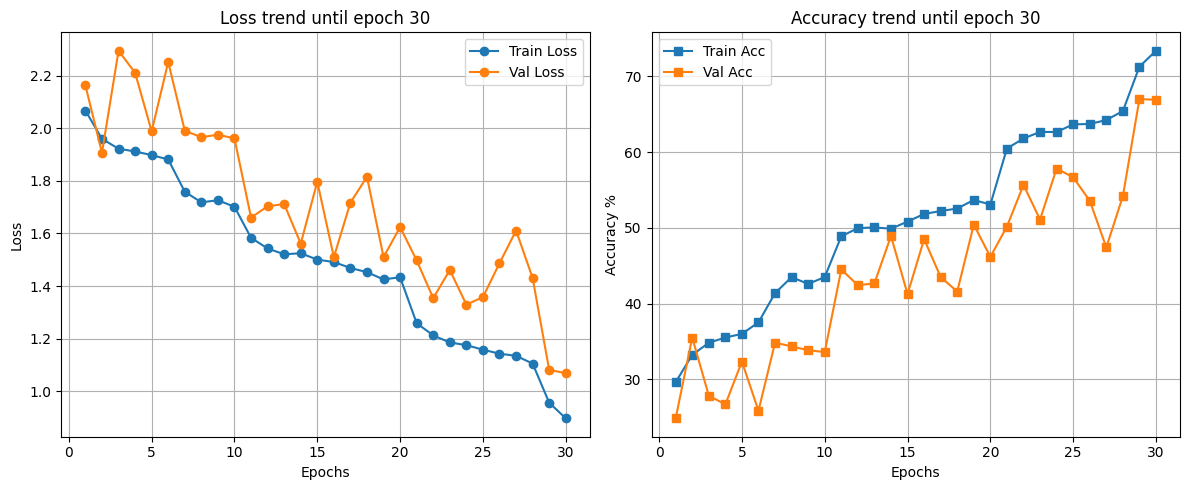

Epoch [31/50]: 100%|██████████| 263/263 [00:37<00:00,  7.10it/s, loss=0.975]



Results: Train Loss: 0.8705 | Val Loss: 1.0664 | Val Accuracy: 67.33%
--> Improvement! Model saving ... (Accuracy: 67.00% -> 67.33%)


Epoch [32/50]: 100%|██████████| 263/263 [00:37<00:00,  7.04it/s, loss=0.722]



Results: Train Loss: 0.8664 | Val Loss: 1.0229 | Val Accuracy: 68.17%
--> Improvement! Model saving ... (Accuracy: 67.33% -> 68.17%)


Epoch [33/50]: 100%|██████████| 263/263 [00:37<00:00,  7.09it/s, loss=1.35]



Results: Train Loss: 0.8427 | Val Loss: 1.0879 | Val Accuracy: 65.58%


Epoch [34/50]: 100%|██████████| 263/263 [00:37<00:00,  7.09it/s, loss=0.952]



Results: Train Loss: 0.8209 | Val Loss: 1.2741 | Val Accuracy: 59.50%


Epoch [35/50]: 100%|██████████| 263/263 [00:37<00:00,  7.02it/s, loss=0.659]



Results: Train Loss: 0.8177 | Val Loss: 1.1921 | Val Accuracy: 62.00%


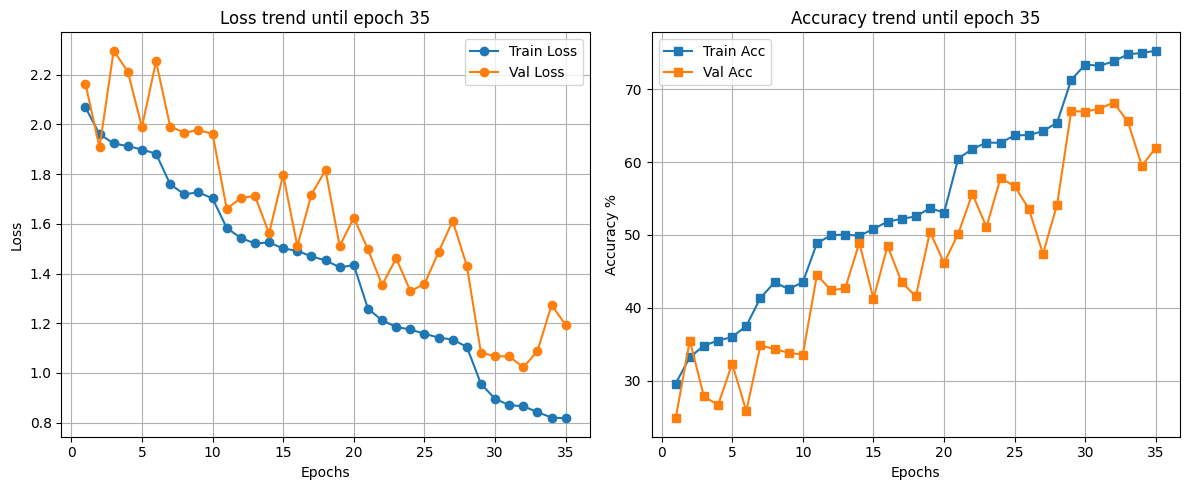

Epoch [36/50]: 100%|██████████| 263/263 [00:37<00:00,  7.08it/s, loss=0.919]



Results: Train Loss: 0.8004 | Val Loss: 1.0782 | Val Accuracy: 65.17%


Epoch [37/50]: 100%|██████████| 263/263 [00:37<00:00,  6.97it/s, loss=0.516]



Results: Train Loss: 0.6479 | Val Loss: 0.8868 | Val Accuracy: 73.33%
--> Improvement! Model saving ... (Accuracy: 68.17% -> 73.33%)


Epoch [38/50]: 100%|██████████| 263/263 [00:36<00:00,  7.12it/s, loss=0.403]



Results: Train Loss: 0.6076 | Val Loss: 0.8775 | Val Accuracy: 74.75%
--> Improvement! Model saving ... (Accuracy: 73.33% -> 74.75%)


Epoch [39/50]: 100%|██████████| 263/263 [00:37<00:00,  7.02it/s, loss=0.831]



Results: Train Loss: 0.5873 | Val Loss: 0.8667 | Val Accuracy: 72.75%


Epoch [40/50]: 100%|██████████| 263/263 [00:37<00:00,  7.00it/s, loss=0.703]



Results: Train Loss: 0.5763 | Val Loss: 0.9546 | Val Accuracy: 70.25%


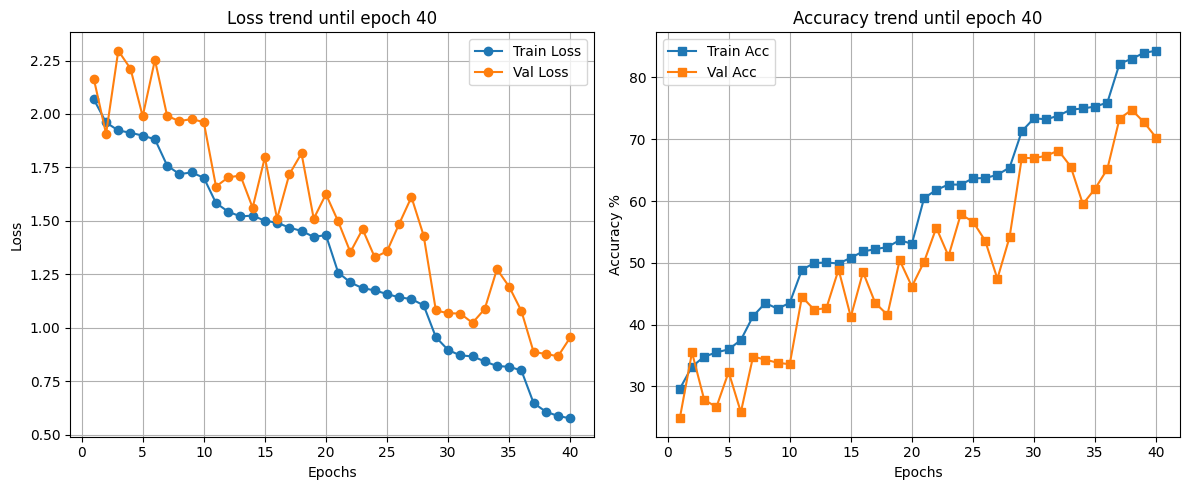

Epoch [41/50]: 100%|██████████| 263/263 [00:37<00:00,  7.05it/s, loss=0.853]



Results: Train Loss: 0.5592 | Val Loss: 0.8893 | Val Accuracy: 72.33%


Epoch [42/50]: 100%|██████████| 263/263 [00:37<00:00,  6.93it/s, loss=0.708]



Results: Train Loss: 0.5428 | Val Loss: 0.8436 | Val Accuracy: 75.25%
--> Improvement! Model saving ... (Accuracy: 74.75% -> 75.25%)


Epoch [43/50]: 100%|██████████| 263/263 [00:37<00:00,  7.05it/s, loss=0.538]



Results: Train Loss: 0.5280 | Val Loss: 0.8353 | Val Accuracy: 74.58%


Epoch [44/50]: 100%|██████████| 263/263 [00:37<00:00,  7.06it/s, loss=0.552]



Results: Train Loss: 0.5233 | Val Loss: 0.8428 | Val Accuracy: 74.00%


Epoch [45/50]: 100%|██████████| 263/263 [00:37<00:00,  6.97it/s, loss=0.337]



Results: Train Loss: 0.4941 | Val Loss: 0.9492 | Val Accuracy: 72.25%


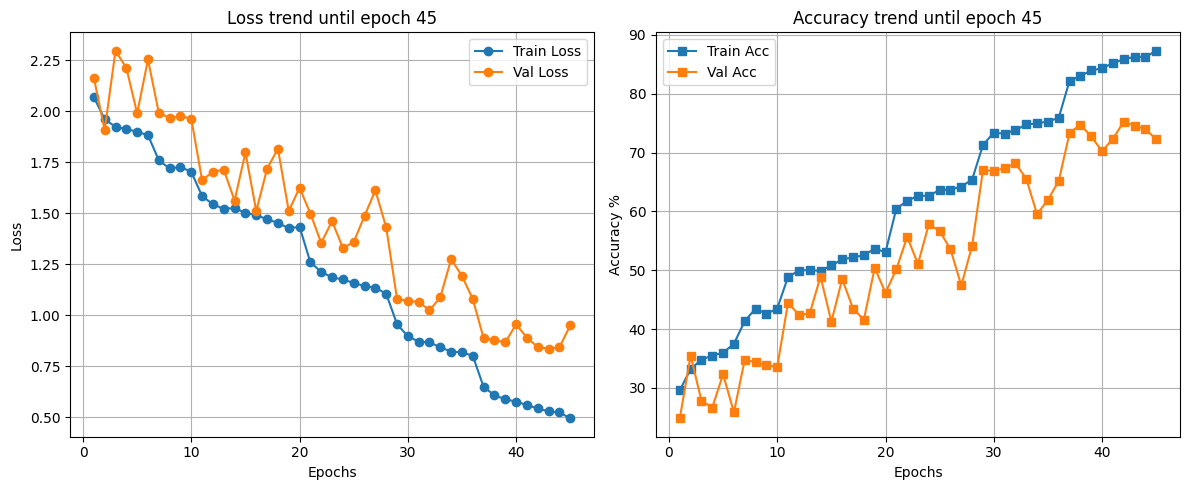

Epoch [46/50]: 100%|██████████| 263/263 [00:37<00:00,  7.06it/s, loss=0.755]



Results: Train Loss: 0.4954 | Val Loss: 0.8775 | Val Accuracy: 74.42%


Epoch [47/50]: 100%|██████████| 263/263 [00:37<00:00,  6.94it/s, loss=0.472]



Results: Train Loss: 0.4878 | Val Loss: 0.8510 | Val Accuracy: 73.67%


Epoch [48/50]: 100%|██████████| 263/263 [00:37<00:00,  6.98it/s, loss=0.256]



Results: Train Loss: 0.3847 | Val Loss: 0.7013 | Val Accuracy: 80.67%
--> Improvement! Model saving ... (Accuracy: 75.25% -> 80.67%)


Epoch [49/50]: 100%|██████████| 263/263 [00:37<00:00,  7.05it/s, loss=0.541]



Results: Train Loss: 0.3540 | Val Loss: 0.6873 | Val Accuracy: 80.42%


Epoch [50/50]: 100%|██████████| 263/263 [00:37<00:00,  6.93it/s, loss=0.806]



Results: Train Loss: 0.3355 | Val Loss: 0.6988 | Val Accuracy: 79.50%


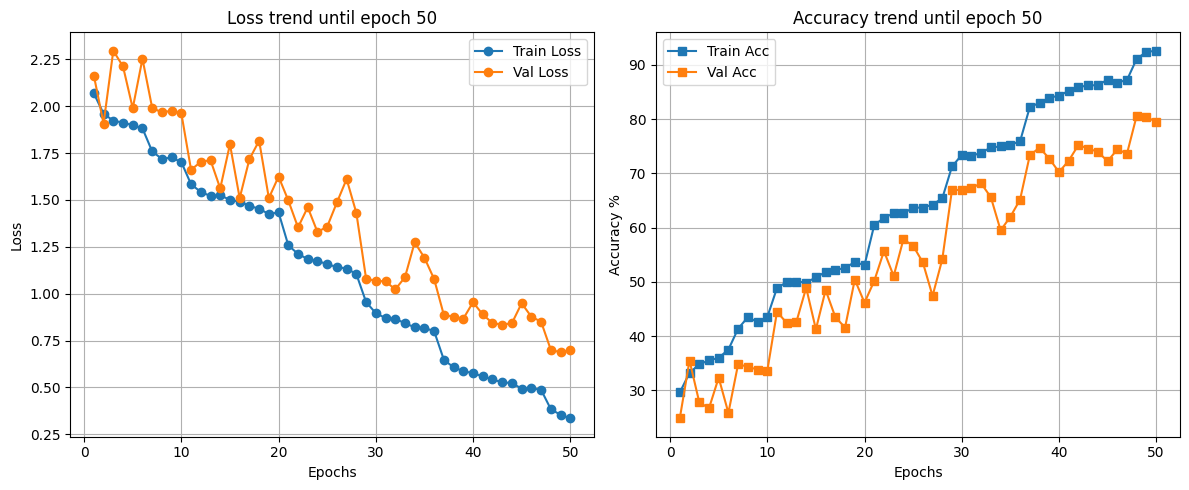

----------------------------------------
Train finnish! Best accuracy reached: 80.67%
Model saved in: /content/dataset/miglior_modello.pth


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

best_val_acc = 0.0
save_path = '/content/dataset/miglior_modello.pth'

num_epochs = 50

for epoch in range(num_epochs):

    # TRAIN
    net.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=True)

    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item())

    train_loss_list.append(running_loss / len(train_loader))
    train_acc_list.append(100 * correct_train / total_train)

    # VALIDATION
    net.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss_list.append(running_val_loss / len(val_loader))
    val_acc_list.append(100 * correct_val / total_val)

    current_val_acc = val_acc_list[-1]

    print(f"\nResults: Train Loss: {train_loss_list[-1]:.4f} | Val Loss: {val_loss_list[-1]:.4f} | Val Accuracy: {current_val_acc:.2f}%")

    scheduler.step(val_loss_list[-1])


    # Best model
    if current_val_acc > best_val_acc:
        print(f"--> Improvement! Model saving ... (Accuracy: {best_val_acc:.2f}% -> {current_val_acc:.2f}%)")
        best_val_acc = current_val_acc
        torch.save(net.state_dict(), save_path) # Si usa net, non model!

    # Plot
    if (epoch + 1) % 5 == 0:
        plt.figure(figsize=(12, 5))

        # Loss graph
        plt.subplot(1, 2, 1)
        plt.plot(range(1, epoch + 2), train_loss_list, label='Train Loss', marker='o')
        plt.plot(range(1, epoch + 2), val_loss_list, label='Val Loss', marker='o')
        plt.title(f'Loss trend until epoch {epoch + 1}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        # Accuracy graph
        plt.subplot(1, 2, 2)
        plt.plot(range(1, epoch + 2), train_acc_list, label='Train Acc', marker='s')
        plt.plot(range(1, epoch + 2), val_acc_list, label='Val Acc', marker='s')
        plt.title(f'Accuracy trend until epoch {epoch + 1}')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy %')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

print("-" * 40)
print(f"Train finnish! Best accuracy reached: {best_val_acc:.2f}%")
print(f"Model saved in: {save_path}")

In [8]:
print(" Test Set start ...")
net.eval()
correct_test = 0
total_test = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)

        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

voto_finale = 100 * correct_test / total_test
print(f"Final test accuracy): {voto_finale:.2f}%")

 Test Set start ...
Final test accuracy): 67.96%
